In [1]:
!pip install pyodbc sqlalchemy pandas faker scikit-learn matplotlib seaborn

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.1 MB 5.5 MB/s eta 0:00:01
   -------------------- ------------------- 1.0/2.1 MB 2.6 MB/s eta 0:00:01
   ------------------------- -------------- 1.3/2.1 MB 2.4 MB/s eta 0:00:01
   ------------------------------ --------- 1.6/2.1 MB 1.9 MB/s eta 0:00:01
   ------------------------------ --------- 1.6/2.1 MB 1.9 MB/s eta 0:00:01
   ------------------------------ --------- 1.6/2.1 MB 1.9 MB/s eta 0:00:01
   ------------------------------ --------- 1.6/2.1 MB 1.9 MB/s eta 0:00:01
   ------------------------------ --------- 1.6/2.1 MB 1.9 MB/s eta 0:00:01
   ----------------------------------- ---- 1.8/2.1 MB 972.8 kB/s eta 0:00:01
   ----------------------------------- ---- 1.8/2.1 MB 972.8 kB/s eta 0:00:01
   ----------------------------------- ---- 1.8/2.1 MB 972.8 kB/s eta 0:00:01
   ----------------------------------- ---- 1.8/2.1 MB 972.8 kB/s eta 0:00:01
   --------

In [3]:
import pyodbc
import pandas as pd
from sqlalchemy import create_engine
import urllib

In [4]:
SERVER = 'localhost\SQLEXPRESS'   # <-- replace with YOUR exact server name from SSMS

conn = pyodbc.connect(
    f'DRIVER={{ODBC Driver 17 for SQL Server}};'
    f'SERVER={SERVER};'
    f'DATABASE=master;'
    f'Trusted_Connection=yes;'
)

print("Connected successfully!")
conn.close()

Connected successfully!


In [5]:
conn = pyodbc.connect(
    f'DRIVER={{ODBC Driver 17 for SQL Server}};'
    f'SERVER={SERVER};'
    f'DATABASE=master;'
    f'Trusted_Connection=yes;',
    autocommit=True
)
cursor = conn.cursor()
cursor.execute("IF NOT EXISTS (SELECT * FROM sys.databases WHERE name = 'SeepageDB') CREATE DATABASE SeepageDB")
print("Database 'SeepageDB' ready.")
conn.close()

Database 'SeepageDB' ready.


In [6]:
DATABASE = 'SeepageDB'

params = urllib.parse.quote_plus(
    f'DRIVER={{ODBC Driver 17 for SQL Server}};'
    f'SERVER={SERVER};'
    f'DATABASE={DATABASE};'
    f'Trusted_Connection=yes;'
)
engine = create_engine(f'mssql+pyodbc:///?odbc_connect={params}')

# test it — should print an empty table since SeepageDB has no tables yet
df = pd.read_sql("SELECT name FROM sys.tables", engine)
print(df)

C:\Users\crswa\anaconda3\Lib\site-packages\pandas\io\sql.py:1636: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


Empty DataFrame
Columns: [name]
Index: []


In [7]:
conn = pyodbc.connect(
    f'DRIVER={{ODBC Driver 17 for SQL Server}};'
    f'SERVER={SERVER};'
    f'DATABASE=SeepageDB;'
    f'Trusted_Connection=yes;',
    autocommit=True
)
cursor = conn.cursor()

create_tables_sql = """
IF NOT EXISTS (SELECT * FROM sys.tables WHERE name = 'Customers')
CREATE TABLE Customers (
    CustomerID INT PRIMARY KEY IDENTITY(1,1),
    CustomerName VARCHAR(100),
    Segment VARCHAR(50),
    SignupDate DATE
);

IF NOT EXISTS (SELECT * FROM sys.tables WHERE name = 'Subscription_Plans')
CREATE TABLE Subscription_Plans (
    PlanID INT PRIMARY KEY IDENTITY(1,1),
    PlanName VARCHAR(50),
    MonthlyPrice DECIMAL(10,2)
);

IF NOT EXISTS (SELECT * FROM sys.tables WHERE name = 'Contracts')
CREATE TABLE Contracts (
    ContractID INT PRIMARY KEY IDENTITY(1,1),
    CustomerID INT FOREIGN KEY REFERENCES Customers(CustomerID),
    PlanID INT FOREIGN KEY REFERENCES Subscription_Plans(PlanID),
    StartDate DATE,
    DiscountPercent DECIMAL(5,2) DEFAULT 0,
    DiscountEndDate DATE NULL,
    ExpectedMonthlyAmount DECIMAL(10,2)
);

IF NOT EXISTS (SELECT * FROM sys.tables WHERE name = 'Invoices')
CREATE TABLE Invoices (
    InvoiceID INT PRIMARY KEY IDENTITY(1,1),
    CustomerID INT FOREIGN KEY REFERENCES Customers(CustomerID),
    ContractID INT FOREIGN KEY REFERENCES Contracts(ContractID),
    InvoiceDate DATE,
    BilledAmount DECIMAL(10,2),
    PaymentStatus VARCHAR(20)
);
"""

for statement in create_tables_sql.split(';'):
    if statement.strip():
        cursor.execute(statement)

print("All tables created successfully.")
conn.close()

All tables created successfully.


In [8]:
df = pd.read_sql("SELECT name FROM sys.tables ORDER BY name", engine)
print(df)

                 name
0           Contracts
1           Customers
2            Invoices
3  Subscription_Plans


In [9]:
from faker import Faker
import random
from datetime import date, timedelta

fake = Faker()
random.seed(42)
Faker.seed(42)

In [10]:
plans = pd.DataFrame({
    'PlanName': ['Basic', 'Standard', 'Premium', 'Enterprise'],
    'MonthlyPrice': [499.00, 999.00, 1999.00, 4999.00]
})

plans.to_sql('Subscription_Plans', engine, if_exists='append', index=False)
plans_db = pd.read_sql("SELECT * FROM Subscription_Plans", engine)
print(plans_db)

   PlanID    PlanName  MonthlyPrice
0       1       Basic         499.0
1       2    Standard         999.0
2       3     Premium        1999.0
3       4  Enterprise        4999.0


In [11]:
NUM_CUSTOMERS = 5000
segments = ['SMB', 'Mid-Market', 'Enterprise']

customers = pd.DataFrame({
    'CustomerName': [fake.company() for _ in range(NUM_CUSTOMERS)],
    'Segment': [random.choice(segments) for _ in range(NUM_CUSTOMERS)],
    'SignupDate': [fake.date_between(start_date='-2y', end_date='-1y') for _ in range(NUM_CUSTOMERS)]
})

customers.to_sql('Customers', engine, if_exists='append', index=False, chunksize=1000)
customers_db = pd.read_sql("SELECT * FROM Customers", engine)
print(customers_db.shape)
print(customers_db.head())

(5000, 4)
   CustomerID                     CustomerName     Segment  SignupDate
0           1  Rodriguez, Figueroa and Sanchez  Enterprise  2025-02-19
1           2                        Doyle Ltd         SMB  2024-10-30
2           3    Mcclain, Miller and Henderson         SMB  2024-12-31
3           4                   Davis and Sons  Enterprise  2025-05-21
4           5      Guzman, Hoffman and Baldwin  Mid-Market  2025-04-30


In [12]:
NUM_CUSTOMERS = 5000
contracts_list = []

for cust_id in range(1, NUM_CUSTOMERS + 1):
    plan_id = random.choice([1, 2, 3, 4])
    monthly_price = plans_db.loc[plans_db['PlanID'] == plan_id, 'MonthlyPrice'].values[0]

    # 40% of customers have a discount
    has_discount = random.random() < 0.40
    discount_percent = random.choice([10, 15, 20, 25, 30]) if has_discount else 0

    start_date = customers_db.loc[customers_db['CustomerID'] == cust_id, 'SignupDate'].values[0]

    # discount valid for 3 months from start, if there is one
    discount_end_date = (pd.to_datetime(start_date) + pd.DateOffset(months=3)).date() if has_discount else None

    expected_amount = round(monthly_price * (1 - discount_percent / 100), 2)

    contracts_list.append({
        'CustomerID': cust_id,
        'PlanID': plan_id,
        'StartDate': start_date,
        'DiscountPercent': discount_percent,
        'DiscountEndDate': discount_end_date,
        'ExpectedMonthlyAmount': expected_amount
    })

contracts = pd.DataFrame(contracts_list)
contracts.to_sql('Contracts', engine, if_exists='append', index=False, chunksize=1000)

contracts_db = pd.read_sql("SELECT * FROM Contracts", engine)
print(contracts_db.shape)
print(contracts_db.head())

(5000, 7)
   ContractID  CustomerID  PlanID   StartDate  DiscountPercent  \
0           1           1       3  2025-02-19              0.0   
1           2           2       3  2024-10-30              0.0   
2           3           3       2  2024-12-31             10.0   
3           4           4       2  2025-05-21             20.0   
4           5           5       3  2025-04-30             25.0   

  DiscountEndDate  ExpectedMonthlyAmount  
0            None                1999.00  
1            None                1999.00  
2      2025-03-31                 899.10  
3      2025-08-21                 799.20  
4      2025-07-30                1499.25  


In [13]:
from dateutil.relativedelta import relativedelta

TODAY = date(2026, 9, 15)   # our fixed "current date" reference
invoices_list = []

for _, row in contracts_db.iterrows():
    cust_id = row['CustomerID']
    contract_id = row['ContractID']
    plan_id = row['PlanID']
    full_price = plans_db.loc[plans_db['PlanID'] == plan_id, 'MonthlyPrice'].values[0]
    discounted_price = row['ExpectedMonthlyAmount']
    discount_end = pd.to_datetime(row['DiscountEndDate']).date() if pd.notnull(row['DiscountEndDate']) else None
    start = pd.to_datetime(row['StartDate']).date()

    invoice_date = start + relativedelta(months=1)  # first invoice one month after signup

    while invoice_date <= TODAY:
        # what SHOULD be billed this month (true expected amount)
        if discount_end and invoice_date > discount_end:
            true_expected = full_price
        else:
            true_expected = discounted_price

        r = random.random()

        if discount_end and invoice_date > discount_end and r < 0.12:
            # LEAKAGE TYPE 1: expired discount still being applied
            billed_amount = discounted_price
            status = 'Paid'
        elif r < 0.05:
            # LEAKAGE TYPE 2: payment failed, never retried
            billed_amount = 0.00
            status = 'Failed'
        elif r < 0.08:
            # LEAKAGE TYPE 3: random billing error (over/undercharge)
            error_factor = random.uniform(0.5, 0.85)
            billed_amount = round(true_expected * error_factor, 2)
            status = 'Paid'
        else:
            # correctly billed
            billed_amount = true_expected
            status = 'Paid'

        invoices_list.append({
            'CustomerID': cust_id,
            'ContractID': contract_id,
            'InvoiceDate': invoice_date,
            'BilledAmount': billed_amount,
            'PaymentStatus': status
        })

        invoice_date = invoice_date + relativedelta(months=1)

invoices = pd.DataFrame(invoices_list)
print("Total invoices generated:", invoices.shape[0])

invoices.to_sql('Invoices', engine, if_exists='append', index=False, chunksize=1000)
print("Invoices loaded into SQL Server.")

Total invoices generated: 87614
Invoices loaded into SQL Server.


In [14]:
invoices_db = pd.read_sql("SELECT TOP 10 * FROM Invoices ORDER BY InvoiceID", engine)
print(invoices_db)

total_count = pd.read_sql("SELECT COUNT(*) AS TotalInvoices FROM Invoices", engine)
print(total_count)

   InvoiceID  CustomerID  ContractID InvoiceDate  BilledAmount PaymentStatus
0          1           1           1  2025-03-19       1999.00          Paid
1          2           1           1  2025-04-19       1999.00          Paid
2          3           1           1  2025-05-19       1999.00          Paid
3          4           1           1  2025-06-19       1657.39          Paid
4          5           1           1  2025-07-19       1999.00          Paid
5          6           1           1  2025-08-19       1999.00          Paid
6          7           1           1  2025-09-19       1999.00          Paid
7          8           1           1  2025-10-19       1999.00          Paid
8          9           1           1  2025-11-19       1999.00          Paid
9         10           1           1  2025-12-19       1300.20          Paid
   TotalInvoices
0          87614


In [15]:
leakage_query = """
SELECT 
    i.InvoiceID,
    i.CustomerID,
    c.Segment,
    i.ContractID,
    i.InvoiceDate,
    i.BilledAmount,
    i.PaymentStatus,
    ct.DiscountEndDate,
    ct.ExpectedMonthlyAmount AS DiscountedExpected,
    p.MonthlyPrice AS FullPrice,
    CASE 
        WHEN ct.DiscountEndDate IS NOT NULL 
             AND i.InvoiceDate > ct.DiscountEndDate 
             AND i.BilledAmount < p.MonthlyPrice
        THEN p.MonthlyPrice
        ELSE ct.ExpectedMonthlyAmount
    END AS TrueExpectedAmount,

    CASE 
        WHEN i.PaymentStatus = 'Failed' THEN 'Failed Payment - No Retry'
        WHEN ct.DiscountEndDate IS NOT NULL 
             AND i.InvoiceDate > ct.DiscountEndDate 
             AND ABS(i.BilledAmount - ct.ExpectedMonthlyAmount) < 1
        THEN 'Expired Discount Still Applied'
        WHEN i.BilledAmount < (
            CASE 
                WHEN ct.DiscountEndDate IS NOT NULL AND i.InvoiceDate > ct.DiscountEndDate 
                THEN p.MonthlyPrice ELSE ct.ExpectedMonthlyAmount 
            END) - 1
        THEN 'Billing Error - Undercharged'
        ELSE 'No Leakage'
    END AS LeakageCategory

FROM Invoices i
JOIN Contracts ct ON i.ContractID = ct.ContractID
JOIN Customers c ON i.CustomerID = c.CustomerID
JOIN Subscription_Plans p ON ct.PlanID = p.PlanID
"""

leakage_df = pd.read_sql(leakage_query, engine)
print(leakage_df.shape)
print(leakage_df['LeakageCategory'].value_counts())

(87614, 12)
LeakageCategory
No Leakage                        79397
Expired Discount Still Applied     3592
Failed Payment - No Retry          2900
Billing Error - Undercharged       1725
Name: count, dtype: int64


In [16]:
leakage_df['LeakageAmount'] = leakage_df['TrueExpectedAmount'] - leakage_df['BilledAmount']
leakage_df.loc[leakage_df['LeakageAmount'] < 0, 'LeakageAmount'] = 0  # only count under-billing as leakage

total_leakage = leakage_df['LeakageAmount'].sum()
print(f"Total revenue leakage detected: ₹{total_leakage:,.2f}")

leakage_by_category = leakage_df.groupby('LeakageCategory')['LeakageAmount'].sum().sort_values(ascending=False)
print(leakage_by_category)

Total revenue leakage detected: ₹8,642,150.59
LeakageCategory
Failed Payment - No Retry         5960452.55
Expired Discount Still Applied    1473677.60
Billing Error - Undercharged      1208020.44
No Leakage                              0.00
Name: LeakageAmount, dtype: float64


In [17]:
leakage_by_segment = leakage_df.groupby('Segment')['LeakageAmount'].sum().sort_values(ascending=False)
print(leakage_by_segment)

invoice_count_by_segment = leakage_df[leakage_df['LeakageAmount'] > 0].groupby('Segment').size()
print(invoice_count_by_segment)

Segment
Enterprise    3036832.04
Mid-Market    2827422.96
SMB           2777895.59
Name: LeakageAmount, dtype: float64
Segment
Enterprise    2854
Mid-Market    2772
SMB           2591
dtype: int64


In [18]:
leakage_df['InvoiceMonth'] = pd.to_datetime(leakage_df['InvoiceDate']).dt.to_period('M')
leakage_by_month = leakage_df.groupby('InvoiceMonth')['LeakageAmount'].sum()
print(leakage_by_month)

InvoiceMonth
2024-10     17780.85
2024-11     53308.56
2024-12    100955.53
2025-01    151091.35
2025-02    191858.31
2025-03    232139.07
2025-04    239766.71
2025-05    277946.97
2025-06    397833.15
2025-07    427207.43
2025-08    463116.85
2025-09    518144.64
2025-10    497230.62
2025-11    496331.17
2025-12    476982.82
2026-01    485870.53
2026-02    447227.02
2026-03    443669.62
2026-04    507629.96
2026-05    499673.85
2026-06    479234.88
2026-07    498618.70
2026-08    524412.51
2026-09    214119.49
Freq: M, Name: LeakageAmount, dtype: float64


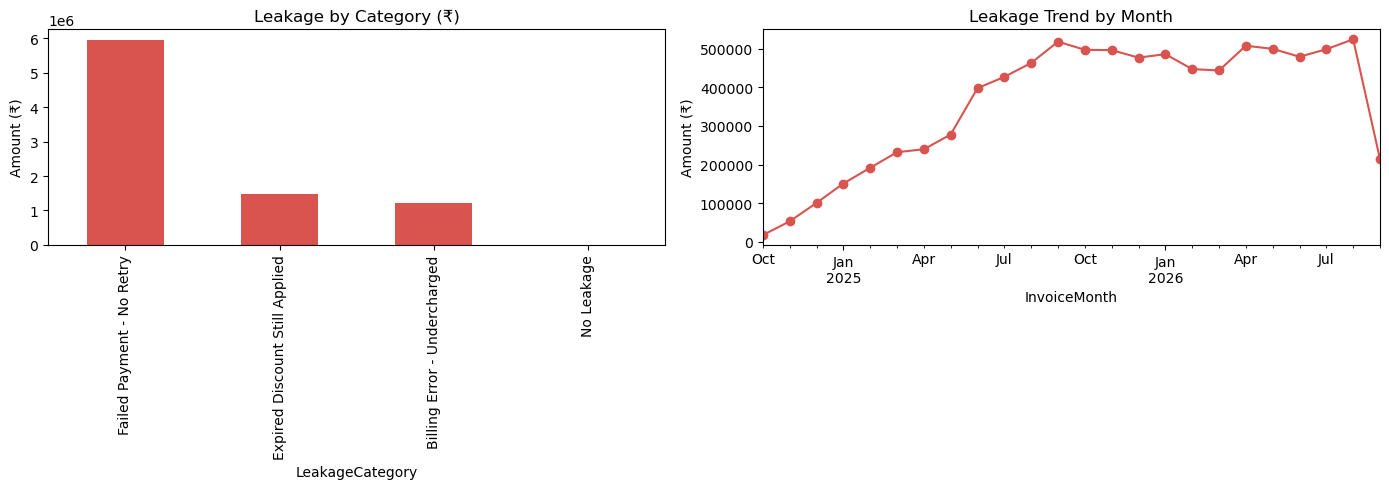

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

leakage_by_category.plot(kind='bar', ax=axes[0], color='#d9534f')
axes[0].set_title('Leakage by Category (₹)')
axes[0].set_ylabel('Amount (₹)')

leakage_by_month.plot(kind='line', marker='o', ax=axes[1], color='#d9534f')
axes[1].set_title('Leakage Trend by Month')
axes[1].set_ylabel('Amount (₹)')

plt.tight_layout()
plt.show()

In [20]:
from sklearn.ensemble import IsolationForest

leakage_df['InvoiceDate'] = pd.to_datetime(leakage_df['InvoiceDate'])
leakage_df['DiscountEndDate'] = pd.to_datetime(leakage_df['DiscountEndDate'])

leakage_df['DaysSinceDiscountEnd'] = (leakage_df['InvoiceDate'] - leakage_df['DiscountEndDate']).dt.days
leakage_df['DaysSinceDiscountEnd'] = leakage_df['DaysSinceDiscountEnd'].fillna(-1)  # -1 = no discount ever

leakage_df['BilledVsExpectedRatio'] = leakage_df['BilledAmount'] / leakage_df['TrueExpectedAmount']
leakage_df['BilledVsExpectedRatio'] = leakage_df['BilledVsExpectedRatio'].replace([float('inf')], 0).fillna(0)

leakage_df['IsFailed'] = (leakage_df['PaymentStatus'] == 'Failed').astype(int)

features = leakage_df[['BilledAmount', 'TrueExpectedAmount', 'BilledVsExpectedRatio', 
                        'DaysSinceDiscountEnd', 'IsFailed']]

print(features.describe())

       BilledAmount  TrueExpectedAmount  BilledVsExpectedRatio  \
count  87614.000000        87614.000000           87614.000000   
mean    1967.415364         1945.590408               1.028409   
std     1715.303306         1642.147281               0.244775   
min        0.000000          349.300000               0.000000   
25%      499.000000          499.000000               1.000000   
50%      999.000000          999.000000               1.000000   
75%     1999.000000         1999.000000               1.111111   
max     4999.000000         4999.000000               1.428571   

       DaysSinceDiscountEnd      IsFailed  
count          87614.000000  87614.000000  
mean              80.788687      0.033100  
std              147.769170      0.178898  
min              -62.000000      0.000000  
25%               -1.000000      0.000000  
50%               -1.000000      0.000000  
75%              122.000000      0.000000  
max              639.000000      1.000000  


In [21]:
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.10,   # we expect ~10% of invoices to be anomalous, matching our known leakage rate
    random_state=42
)

leakage_df['AnomalyScore'] = iso_forest.fit_predict(features)
leakage_df['IsAnomaly'] = (leakage_df['AnomalyScore'] == -1).astype(int)

print(leakage_df['IsAnomaly'].value_counts())

# how well does it agree with our rule-based detection?
comparison = pd.crosstab(leakage_df['LeakageCategory'], leakage_df['IsAnomaly'])
print(comparison)

IsAnomaly
0    78854
1     8760
Name: count, dtype: int64
IsAnomaly                           0     1
LeakageCategory                            
Billing Error - Undercharged     1255   470
Expired Discount Still Applied   2103  1489
Failed Payment - No Retry           0  2900
No Leakage                      75496  3901


In [23]:
leakage_df['FinalFlag'] = ((leakage_df['LeakageCategory'] != 'No Leakage') | (leakage_df['IsAnomaly'] == 1)).astype(int)

print(f"Total invoices flagged (rules OR ML): {leakage_df['FinalFlag'].sum()}")
print(f"Total leakage amount (all flagged): ₹{leakage_df.loc[leakage_df['FinalFlag']==1, 'LeakageAmount'].sum():,.2f}")

Total invoices flagged (rules OR ML): 12118
Total leakage amount (all flagged): ₹8,642,150.59


In [24]:
final_table = leakage_df[['InvoiceID', 'CustomerID', 'Segment', 'InvoiceDate', 'InvoiceMonth',
                            'BilledAmount', 'TrueExpectedAmount', 'LeakageAmount', 
                            'LeakageCategory', 'IsAnomaly', 'FinalFlag']].copy()
final_table['InvoiceMonth'] = final_table['InvoiceMonth'].astype(str)

final_table.to_sql('Leakage_Analysis', engine, if_exists='replace', index=False, chunksize=1000)
print("Leakage_Analysis table created in SQL Server — ready for Power BI.")

Leakage_Analysis table created in SQL Server — ready for Power BI.


In [25]:
import os
print(os.getcwd())

C:\Users\crswa
